# Машинное обучение, ФКН ВШЭ

# Практическое задание 10. Рекомендательные системы

## Общая информация
**Дата выдачи: 24.03.2026**

**Мягкий дедлайн: 10.04.2026 23:59 MSK**

**Жёсткий дедлайн: 18.04.2026 23:59 MSK** 

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — **11** баллов + **2.5** бонусных.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-10-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этой работе мы будем решать задачу рекомендации музыки (звуууук). То есть мы поставим целью получить модель, которая для каждого пользователя будет возвращать набор треков, наиболее похожих на те, что он уже слушал. В первой части мы разберемся с memory-based подходом и моделью со скрытыми переменными. Это не очень мощные методы, но зато они позволяют строить предсказания почти моментально. Затем, во второй части, мы обратим внимание на то, что датасет содержит огромное число треков и воспользуемся результатами уже построенных быстрых моделей для сокращения списка кандидатов до разумного количества. После этого проведем ранжирование среди кандидатов с помощью сильной, но чуть более медленной модели, и отберем самые лучшие варианты. Такой двухэтапный алгоритм построения рекомендаций изображен на картинке.


![](https://i.ibb.co/4RptSVjp/Screenshot-2026-03-23-at-00-29-18.png)

Приступим!

Все шаблоны ниже можно переписывать по своему усмотрению.

In [2]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [6]:
ratings = pd.read_csv('/kaggle/input/datasets/ivanbrazil/music-dataset/music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [10]:
tracks_info = pd.read_csv('/kaggle/input/datasets/ivanbrazil/tracks-info/tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

**Задание 1 (0.5 балл).** Реализуйте метрику $MAP@k$.

In [14]:
def mapk(relevant, predicted, k=20):
    def apk(relevant_apk, predicted_apk):
        relevant_set = set(relevant_apk)
        apk_score = 0

        for i in range(min(k, len(predicted_apk))):
            if predicted_apk[i] in relevant_set:
                p = 0
                for j in range(i + 1):
                    p += (predicted_apk[j] in relevant_set)
                p /= (i + 1)

                apk_score += p

        return apk_score / min(k, len(relevant_apk))

    ans = 0
    for rel, pred in zip(relevant, predicted):
        ans += apk(rel, pred)

    return ans / len(relevant)


In [15]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [16]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [17]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [18]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [19]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [20]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [21]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [22]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Соберем все релевантные треки для каждого пользователя в список.

In [25]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Задание 2 (0.5 балла).** Реализуйте метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забывайте удалять уже прослушанные треки из рекомендуемых.

In [43]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.
        
    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_users = np.unique(self.ratings['userId'])
        test_preds = []
    
        for uid in range(self.n_users):
            test_preds.append(self.recommend(uid))
    
        test_preds = np.array(test_preds)
        test_preds = self.remove_train_items(test_preds, k)
    
        return test_preds[test_users]


### Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать меру Жаккара:

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Во всех формулах 
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Задание 3.2 (0.5 балла).** Реализуйте функцию подсчета меры Жаккара.

Функция принимает матрицу оценок и вектор оценок пользователя $u$ и возвращает вектор со значениями похожести пользователя $u$ на всех пользователей. Старайтесь писать оптимизированный код, за неэффективную реализацию оценка может быть снижена.

In [44]:
def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    intersection = np.logical_and(ratings, user_vector).sum(axis=1)
    union = np.logical_or(ratings, user_vector).sum(axis=1)

    sim = np.zeros(ratings.shape[0])
    mask = union != 0
    sim[mask] = intersection[mask] / union[mask]

    return sim


**Задание 4 (1 балл).** Реализуйте методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок. Значение параметра `alpha` можно менять по своему усмотрению так, чтобы оно было разумным.

In [45]:
class User2User(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        return self.similarity_func(self.R, user_vector)

    def recommend(self, uid: int):
        user_vector = self.R[uid]

        sim = self.similarity(user_vector)
        sim[uid] = 0

        neighbours = sim > self.alpha

        if np.sum(neighbours) == 0:
            scores = np.zeros(self.n_items)
        else:
            scores = (sim[neighbours] @ self.R[neighbours]) / np.sum(np.abs(sim[neighbours]))

        return np.argsort(scores)[::-1]

**Задание 5 (0.5 балл).** Постройте график зависимости значений $MAP@k$ от разных $k$ при рекомендации на основе меры Жаккара, сравните его с рекомендациями самых популярных треков и случайных. Какой из трех способов рекомендаций оказался лучшим?

/tmp/ipykernel_55/905265598.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]
/tmp/ipykernel_55/1080087380.py:27: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  popular_user_pred = popular_order[~np.in1d(popular_order, train_user_tracks)][:k]
/tmp/ipykernel_55/1080087380.py:31: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  random_user_pred = random_order[~np.in1d(random_order, train_user_tracks)][:k]


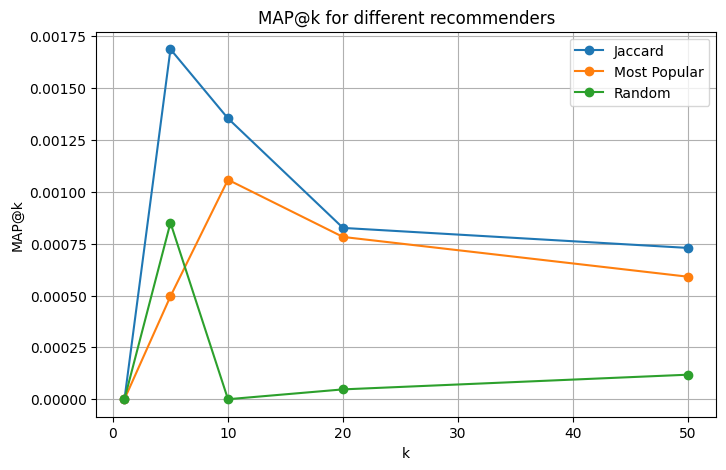

In [31]:
ks = [1, 5, 10, 20, 50]

user2user_model = User2User(train_ratings)

test_users = np.unique(test_ratings['userId'])
test_relevant = []

for uid in test_users:
    user_tracks = test_ratings[test_ratings['userId'] == uid]['trackId'].tolist()
    test_relevant.append(user_tracks)

popular_order = train_ratings['trackId'].value_counts().index.to_numpy()

jaccard_scores = []
popular_scores = []
random_scores = []

for k in ks:
    jaccard_preds = user2user_model.get_test_recommendations(k).tolist()

    popular_preds = []
    random_preds = []

    for uid in test_users:
        train_user_tracks = train_ratings[train_ratings['userId'] == uid]['trackId'].values

        popular_user_pred = popular_order[~np.in1d(popular_order, train_user_tracks)][:k]
        popular_preds.append(popular_user_pred.tolist())

        random_order = np.random.permutation(user2user_model.n_items)
        random_user_pred = random_order[~np.in1d(random_order, train_user_tracks)][:k]
        random_preds.append(random_user_pred.tolist())

    jaccard_scores.append(mapk(test_relevant, jaccard_preds, k))
    popular_scores.append(mapk(test_relevant, popular_preds, k))
    random_scores.append(mapk(test_relevant, random_preds, k))

plt.figure(figsize=(8, 5))
plt.plot(ks, jaccard_scores, marker='o', label='Jaccard')
plt.plot(ks, popular_scores, marker='o', label='Most Popular')
plt.plot(ks, random_scores, marker='o', label='Random')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('MAP@k for different recommenders')
plt.legend()
plt.grid()
plt.show()


Ожидаемо, хоть сколько-то идейно логичный алгоритм оказался лучше чем просто самые популярные треки (хоть и не слишком сильно) и рандомные треки

**Бонус (1 балла).** Как вы могли заметить, матрица оценок получается очень разреженной, но мы работаем с ней как с обычной, это не дело. Перепишите код так, чтобы все методы могли работать с разреженными матрицами и сравните скорость работы такого подхода с оригинальным.

In [58]:
from scipy.sparse import csr_matrix

def jaccard_sparse(ratings, user_vector):
    intersection = ratings.multiply(user_vector).sum(axis=1).A1
    ratings_sum = ratings.sum(axis=1).A1
    user_sum = user_vector.sum()
    union = ratings_sum + user_sum - intersection

    sim = np.zeros(ratings.shape[0])
    mask = union != 0
    sim[mask] = intersection[mask] / union[mask]

    return sim


class User2UserSparse:
    def __init__(self, ratings):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = csr_matrix(
            (
                np.ones(len(self.ratings)),
                (self.ratings['userId'], self.ratings['trackId'])
            ),
            shape=(self.n_users, self.n_items)
        )

        self.alpha = 0.02

    def similarity(self, user_vector):
        return jaccard_sparse(self.R, user_vector)

    def recommend(self, uid: int):
        user_vector = self.R[uid]

        sim = self.similarity(user_vector)
        sim[uid] = 0

        neighbours = sim > self.alpha

        if np.sum(neighbours) == 0:
            scores = np.zeros(self.n_items)
        else:
            scores = sim[neighbours] @ self.R[neighbours]
            scores = np.asarray(scores).ravel() / np.sum(np.abs(sim[neighbours]))

        return np.argsort(scores)[::-1]

    def remove_train_items(self, preds, k: int):
        new_preds = np.zeros((len(preds), k), dtype=int)

        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_users = np.unique(self.ratings['userId'])
        test_preds = []

        for uid in range(self.n_users):
            test_preds.append(self.recommend(uid))

        test_preds = np.array(test_preds)
        test_preds = self.remove_train_items(test_preds, k)

        return test_preds[test_users]


In [59]:
import time

model_dense = User2User(train_ratings)
start = time.time()
preds_dense = model_dense.get_test_recommendations(20)
dense_time = time.time() - start

model_sparse = User2UserSparse(train_ratings)
start = time.time()
preds_sparse = model_sparse.get_test_recommendations(20)
sparse_time = time.time() - start

print("Dense time:", dense_time)
print("Sparse time:", sparse_time)


/tmp/ipykernel_55/905265598.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


Dense time: 17.872746229171753
Sparse time: 1.3119702339172363


/tmp/ipykernel_55/954749258.py:56: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


Мы можем посмотреть глазами, насколько хорошо модель рекомендует треки. Для этого сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя. Хорошо ли у вас получилось?

In [66]:
user_id = np.random.randint(0, user2user_model.n_users)

In [67]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
18,Have You Ever Seen The Rain,['Creedence Clearwater Revival']
46,Stop,"['Sam Brown', 'Pete Brown']"
90,Delilah,['Tom Jones']
582,The Winner Takes It All,['ABBA']
598,Obsession,['Army Of Lovers']
663,You Never Can Tell,['Chuck Berry']
665,Johnny B. Goode,['Chuck Berry']
764,I Will Survive,['Gloria Gaynor']
977,Flash In The Night,['Secret Service']
1056,Don't Speak,['No Doubt']


In [68]:
preds = user2user_model.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

Predicted tracks:


/tmp/ipykernel_55/905265598.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


,name,artists
5395,Englishman In New York,['Sting']
11136,Beautiful Life,['Ace of Base']
9438,Что такое осень,['ДДТ']
846,Send Me An Angel,['Scorpions']
20620,Cheri Cheri Lady,['Modern Talking']
3825,It Must Have Been Love,['Roxette']
805,Zombie,['The Cranberries']
9433,В последнюю осень,['ДДТ']
1019,It's My Life,['Bon Jovi']
13433,Voyage Voyage,['Desireless']


In [69]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
16519,Strangers By Night,['C.C. Catch']
16605,Новогодняя 2012,['Дискотека Авария']
16635,Pacific,['Zodiac']
16637,Zodiac,['Zodiac']
17632,Человек в телогрейке,['Иван Кучин']
17819,YMCA,['Village People']
18165,Bang a Gong (Get It on),['T. Rex']
18565,Toca Toca,['Fly Project']
20058,Say You'll Never,['Lian Ross']
20314,Ghmorni,['Myriam Fares']


### Часть 2. Модель со скрытыми переменными: ALS

В этой части мы пощупаем метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно. 

Оптимизировать мы будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

__P. S.__ Заметьте, что описанная модель предназначена для работы только с __явной__ информацией. В нашем случае от модели будет требоваться всегда возвращать 1, так как мы считаем ошибку только по парам, о которых получили фидбек. Поэтому логично подумать, что постановка задачи не имеет смысла. Однако, на практике оказывается, что из-за случайности в инициализации матриц $P$ и $Q$, обученные векторы для всех треков и пользователей в конце обучения получаются разными. Поэтому модель все же не лишена смысла.

__P. P. S.__ Для более разумной работы с неявной информацией был предложен метод iALS, его описание можно найти в лекции. Ниже будет бонус на его реализацию.

**Задание 6 (0.5 балла).** На лекции рассматривались два подхода к оптимизации параметров. Можно это делать обычным стохастическим градинтным спуском, а можно по очереди обновлять матрицы $P, Q$, и тогда получится метод Alternating Least Squares (ALS). Выведите формулы обновления параметров для обоих методов.

**SGD:**

Ответ

Рассмотрим функцию потерь для одной пары $(u,i)$:

$L_{ui} = (p_u^\top q_i - r_{ui})^2 + \lambda \|p_u\|^2 + \lambda \|q_i\|^2$

Обозначим ошибку:

$e_{ui} = p_u^\top q_i - r_{ui}$

Тогда градиенты:

$\frac{\partial L_{ui}}{\partial p_u} = 2 e_{ui} q_i + 2\lambda p_u$

$\frac{\partial L_{ui}}{\partial q_i} = 2 e_{ui} p_u + 2\lambda q_i$

Тогда новые веса:

$p_u = p_u - \eta \left(2 e_{ui} q_i + 2\lambda p_u\right)$

$q_i = q_i - \eta \left(2 e_{ui} p_u + 2\lambda q_i\right)$

**ALS:**

Зафиксируем матрицу $Q$ и будем оптимизировать только $p_u$:

$L(p_u) = \sum_{i \in I_u} (p_u^\top q_i - r_{ui})^2 + \lambda \|p_u\|^2$

Возьмем градиент по $p_u$:

$\frac{\partial L}{\partial p_u} = \sum_{i \in I_u} 2 (p_u^\top q_i - r_{ui}) q_i + 2\lambda p_u$

Приравниваем к нулю:

$\sum_{i \in I_u} (p_u^\top q_i - r_{ui}) q_i + \lambda p_u = 0$

Раскрываем:

$\sum_{i \in I_u} q_i q_i^\top p_u - \sum_{i \in I_u} r_{ui} q_i + \lambda p_u = 0$

Собираем члены с $p_u$:

$\left(\sum_{i \in I_u} q_i q_i^\top + \lambda I\right) p_u = \sum_{i \in I_u} r_{ui} q_i$

Отсюда:

$p_u = \left(\sum_{i \in I_u} q_i q_i^\top + \lambda I\right)^{-1} \left(\sum_{i \in I_u} r_{ui} q_i\right)$

Аналогично, фиксируя $P$ и оптимизируя $q_i$, получаем:

$L(q_i) = \sum_{u \in U_i} (p_u^\top q_i - r_{ui})^2 + \lambda \|q_i\|^2$

$\frac{\partial L}{\partial q_i} = \sum_{u \in U_i} 2 (p_u^\top q_i - r_{ui}) p_u + 2\lambda q_i$

Приравниваем к нулю:

$\left(\sum_{u \in U_i} p_u p_u^\top + \lambda I\right) q_i = \sum_{u \in U_i} r_{ui} p_u$

Следовательно,

$q_i = \left(\sum_{u \in U_i} p_u p_u^\top + \lambda I\right)^{-1} \left(\sum_{u \in U_i} r_{ui} p_u\right)$



**Задание 7 (1.5 балла).** Реализуйте методы оптимизации параметров для обоих алгоритмов.

In [74]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd'):
        super().__init__(ratings)
        self.dim = dim
        
        assert mode in ['sgd', 'als']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = 0.0003
        self.lamb = 0.01

    def fit(self, num_iters=5):
        Q = self.Q
        P = self.P
        for epoch in tqdm(range(num_iters)):

            if self.mode == 'sgd':
                for _, row in self.ratings.iterrows():
                    u = row['userId']
                    i = row['trackId']
                    r_ui = 1
            
                    p_u = self.P[u].copy()
                    q_i = self.Q[i].copy()
            
                    err = p_u @ q_i - r_ui
            
                    self.P[u] -= self.lr*(2*err*q_i + 2 *self.lamb *p_u)
                    self.Q[i] -= self.lr*(2*err*p_u + 2 *self.lamb *q_i)


            elif self.mode == 'als':
                for u in range(self.n_users):
                    item_ids = self.ratings[self.ratings['userId'] == u]['trackId'].values
            
                    Q_u = self.Q[item_ids]
                    r_u = np.ones(len(item_ids))
            
                    A = Q_u.T @ Q_u + self.lamb * np.eye(self.dim)
                    b = Q_u.T @ r_u
                    self.P[u] = np.linalg.solve(A, b)
            
                for i in range(self.n_items):
                    user_ids = self.ratings[self.ratings['trackId'] == i]['userId'].values            
                    P_i = self.P[user_ids]
                    r_i = np.ones(len(user_ids))
            
                    A = P_i.T @ P_i + self.lamb * np.eye(self.dim)
                    b = P_i.T @ r_i
                    self.Q[i] = np.linalg.solve(A, b)


    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T

        return np.argsort(pred_rating)[::-1]

**Задание 8 (1 балл).** Для обоих алгоритмов подберите оптимальные значения размерности скрытого пространства $d$ и размера предсказания $k$. Как изменяется качество предсказаний с числом итераций обучения? Постройте соответствующие графики, сравните со случайным подходом и User2User, сделайте выводы. Какой алгоритм вам кажется более подходящим для данной задачи и почему?

__P. S.__ Хотя бы один из методов обучения должен приводить к лучшим результатам в сравнении с User2User подходом.

__P. P. S.__ Методу SGD свойственно переобучаться, поэтому при подборе параметров полезно смотреть на значения ошибки и оптимизируемой метрики на тренировочном датасете. Вы также можете менять начальную инициализацию и прочие параметры, за исключением архитектуры, на ваш вкус.

In [73]:
k = 20

test_users = np.unique(test_ratings['userId'])
test_relevant = []

for uid in test_users:
    user_tracks = test_ratings[test_ratings['userId'] == uid]['trackId'].tolist()
    test_relevant.append(user_tracks)

sgd_dims = [16, 32, 64, 128]
sgd_lrs = [0.001, 0.0003, 0.0001]

best_sgd_score = -1
best_sgd_dim = None
best_sgd_lr = None

for dim in sgd_dims:
    for lr in sgd_lrs:
        np.random.seed(42)

        model = LatentFactorModel(train_ratings, dim=dim, mode='sgd')
        model.lr = lr
        model.fit(num_iters=5)

        preds = model.get_test_recommendations(k)
        score = mapk(test_relevant, preds.tolist(), k)

        print('SGD: dim =', dim, ', lr =', lr, ', MAP@20 =', score)

        if score > best_sgd_score:
            best_sgd_score = score
            best_sgd_dim = dim
            best_sgd_lr = lr

print('Best SGD dim =', best_sgd_dim)
print('Best SGD lr =', best_sgd_lr)
print('Best SGD MAP@20 =', best_sgd_score)


  0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_55/905265598.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


SGD: dim = 16 , lr = 0.001 , MAP@20 = 7.092198581560284e-05


  0%|          | 0/5 [00:00<?, ?it/s]

SGD: dim = 16 , lr = 0.0003 , MAP@20 = 0.0


...

SGD: dim = 128 , lr = 0.001 , MAP@20 = 3.977010737105592e-05


  0%|          | 0/5 [00:00<?, ?it/s]

SGD: dim = 128 , lr = 0.0003 , MAP@20 = 6.662463417617887e-05


  0%|          | 0/5 [00:00<?, ?it/s]

SGD: dim = 128 , lr = 0.0001 , MAP@20 = 7.288150592280755e-05
Best SGD dim = 64
Best SGD lr = 0.001
Best SGD MAP@20 = 0.00024092615769712142


In [77]:
k = 20

test_users = np.unique(test_ratings['userId'])
test_relevant = []

for uid in test_users:
    user_tracks = test_ratings[test_ratings['userId'] == uid]['trackId'].tolist()
    test_relevant.append(user_tracks)

als_dims = [16, 32, 64, 128, 256]

best_als_score = -1
best_als_dim = None

for dim in als_dims:
    np.random.seed(42)

    model = LatentFactorModel(train_ratings, dim=dim, mode='als')
    model.fit(num_iters=5)

    preds = model.get_test_recommendations(k)
    score = mapk(test_relevant, preds.tolist(), k)

    print('ALS: dim =', dim, ', MAP@20 =', score)

    if score > best_als_score:
        best_als_score = score
        best_als_dim = dim

print()
print('Best ALS dim =', best_als_dim)
print('Best ALS MAP@20 =', best_als_score)


  0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_55/905265598.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


ALS: dim = 16 , MAP@20 = 0.0007596370649529203


  0%|          | 0/5 [00:00<?, ?it/s]

ALS: dim = 32 , MAP@20 = 0.0005961967297353635


...

ALS: dim = 64 , MAP@20 = 0.0007094040711061988


  0%|          | 0/5 [00:00<?, ?it/s]

ALS: dim = 128 , MAP@20 = 0.0014816491393462611


  0%|          | 0/5 [00:00<?, ?it/s]

ALS: dim = 256 , MAP@20 = 0.0004728553235403904

Best ALS dim = 128
Best ALS MAP@20 = 0.0014816491393462611


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_55/905265598.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


k=1: Jaccard MAP=0.0000, SGD MAP=0.0043, ALS MAP=0.0128
k=3: Jaccard MAP=0.0012, SGD MAP=0.0014, ALS MAP=0.0057
k=5: Jaccard MAP=0.0017, SGD MAP=0.0009, ALS MAP=0.0040
k=10: Jaccard MAP=0.0014, SGD MAP=0.0004, ALS MAP=0.0027
k=20: Jaccard MAP=0.0008, SGD MAP=0.0002, ALS MAP=0.0015
k=30: Jaccard MAP=0.0007, SGD MAP=0.0002, ALS MAP=0.0011
k=50: Jaccard MAP=0.0007, SGD MAP=0.0002, ALS MAP=0.0009
k=70: Jaccard MAP=0.0008, SGD MAP=0.0002, ALS MAP=0.0010


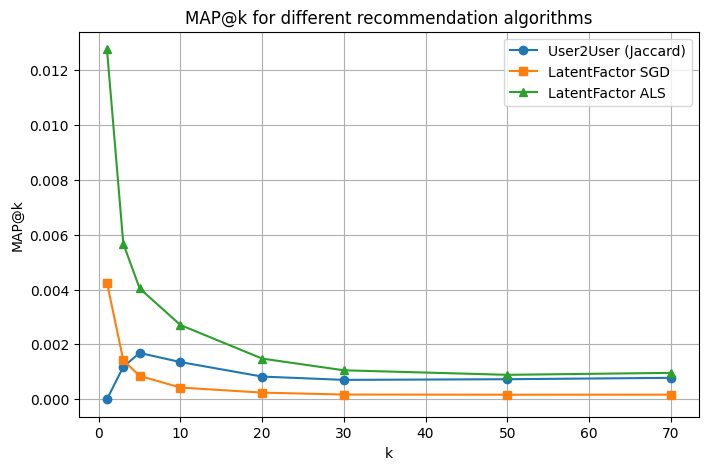

In [78]:
test_users = np.unique(test_ratings['userId'])
test_relevant = []
for uid in test_users:
    user_tracks = test_ratings[test_ratings['userId'] == uid]['trackId'].tolist()
    test_relevant.append(user_tracks)


user2user_model = User2User(train_ratings)


np.random.seed(42)
sgd_model = LatentFactorModel(train_ratings, dim=64, mode='sgd')
sgd_model.lr = 0.001
sgd_model.fit(num_iters=5)


np.random.seed(42)
als_model = LatentFactorModel(train_ratings, dim=128, mode='als')
als_model.fit(num_iters=5)



ks = [1, 3, 5, 10, 20, 30, 50, 70]  

jaccard_scores = []   
sgd_scores = []       
als_scores = []       

for k in ks:

    jaccard_preds = user2user_model.get_test_recommendations(k).tolist()
    score_j = mapk(test_relevant, jaccard_preds, k)
    jaccard_scores.append(score_j)


    sgd_preds = sgd_model.get_test_recommendations(k).tolist()
    score_s = mapk(test_relevant, sgd_preds, k)
    sgd_scores.append(score_s)


    als_preds = als_model.get_test_recommendations(k).tolist()
    score_a = mapk(test_relevant, als_preds, k)
    als_scores.append(score_a)

    print(f'k={k}: Jaccard MAP={score_j:.4f}, SGD MAP={score_s:.4f}, ALS MAP={score_a:.4f}')


plt.figure(figsize=(8, 5))
plt.plot(ks, jaccard_scores, marker='o', label='User2User (Jaccard)')
plt.plot(ks, sgd_scores, marker='s', label='LatentFactor SGD')
plt.plot(ks, als_scores, marker='^', label='LatentFactor ALS')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('MAP@k for different recommendation algorithms')
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_55/905265598.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


  0%|          | 0/1 [00:00<?, ?it/s]

num_iters=1: SGD=0.000000, ALS=0.008511


  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

num_iters=10: SGD=0.000000, ALS=0.012766


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

num_iters=15: SGD=0.000000, ALS=0.012766


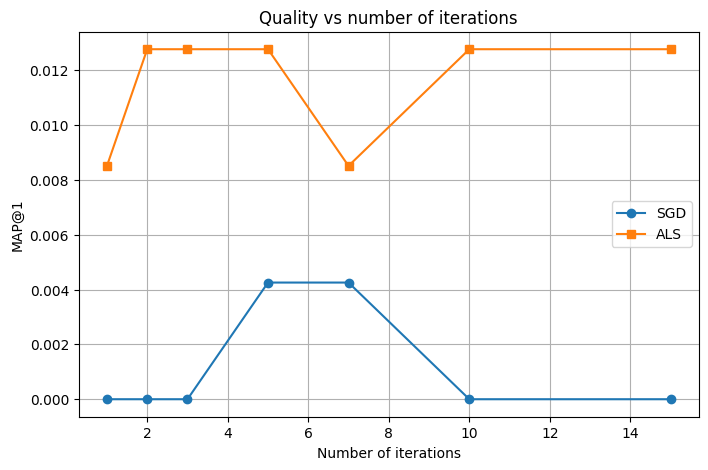

In [79]:
k = 1
iters = [1, 2, 3, 5, 7, 10, 15]

test_users = np.unique(test_ratings['userId'])
test_relevant = []

for uid in test_users:
    user_tracks = test_ratings[test_ratings['userId'] == uid]['trackId'].tolist()
    test_relevant.append(user_tracks)

sgd_scores = []
als_scores = []

for num_iters in iters:
    np.random.seed(42)
    sgd_model = LatentFactorModel(train_ratings, dim=64, mode='sgd')
    sgd_model.lr = 0.001
    sgd_model.fit(num_iters=num_iters)
    sgd_preds = sgd_model.get_test_recommendations(k)
    sgd_score = mapk(test_relevant, sgd_preds.tolist(), k)
    sgd_scores.append(sgd_score)

    np.random.seed(42)
    als_model = LatentFactorModel(train_ratings, dim=128, mode='als')
    als_model.fit(num_iters=num_iters)
    als_preds = als_model.get_test_recommendations(k)
    als_score = mapk(test_relevant, als_preds.tolist(), k)
    als_scores.append(als_score)

    print(f'num_iters={num_iters}: SGD={sgd_score:.6f}, ALS={als_score:.6f}')

plt.figure(figsize=(8, 5))
plt.plot(iters, sgd_scores, marker='o', label='SGD')
plt.plot(iters, als_scores, marker='s', label='ALS')
plt.xlabel('Number of iterations')
plt.ylabel(f'MAP@{k}')
plt.title('Quality vs number of iterations')
plt.legend()
plt.grid(True)
plt.show()


По полученным результатам для задачи рекомендации треков более подходящим выглядит ALS, тк стабильно дает более высокие значения MAP@k, чем SGD. ALS чаще ставит действительно релевантные треки выше в списке рекомендаций

Если у вас получилось достаточно хорошее качество, то при оптимизации параметров марицы $Q$ похожим трекам стали соответствовать похожие векторы. Поэтому мы можем для любого трека найти наиболее близкие к нему в латентном пространстве и проверить степерь обученности модели вручную.

In [82]:
model = LatentFactorModel(train_ratings, dim=128, mode='als')
model.fit(num_iters=5)

example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

preds = model.Q @ model.Q[example_trackId]
preds = preds / np.sqrt((model.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

  0%|          | 0/5 [00:00<?, ?it/s]

In [84]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(model.Q[example_trackId])
similar_tracks

,name,artists,similarity
5512,Выхода нет,['Сплин'],1.000000
2058,Последний герой,['КИНО'],0.729599
5570,Моё сердце,['Сплин'],0.656332
2179,Восьмиклассница,['КИНО'],0.626872
5153,Stormbringer,['Deep Purple'],0.613610
9689,Bicycle Race,['Queen'],0.613610
16637,Zodiac,['Zodiac'],0.613610
16224,Пока горит свеча,['Машина времени'],0.596631
26075,Лошадка,['Найк Борзов'],0.574366
16192,Однажды мир прогнётся под нас,['Машина времени'],0.568854


**Бонус (1.5 балла).**

Постройте модель iALS и сравните ее качество с обучением ALS и SGD.

In [ ]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪

### Часть 3. Второй уровень рекомендаций.

Выше мы построили простейшие модели, которые показывают не слишком высокое качество, но зато работают очень быстро. Воспользуемся ими для того, чтобы отобрать некоторое количество наиболее перспективных треков, которые мы сможем отранжировать уже более сложной моделью (в нашем случае это будет [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboost)).

**Задание 9 (1 балл).**

Для каждого пользователя возьмите топ-100 рекомендованных треков от модели LFM (ALS или SGD на ваш выбор) и топ-100 от модели User2User. Это будут наши кандидаты, которые мы затем будем ранжировать бустингом.

In [86]:
model = LatentFactorModel(train_ratings, dim=128, mode='als')
model.fit(num_iters=5)

user2user_model = User2User(train_ratings)
test_users = np.unique(test_ratings['userId'])

lfm_preds = model.get_test_recommendations(100)
user2user_preds = user2user_model.get_test_recommendations(100)

lfm_top100 = {}
user2user_top100 = {}
all_candidates = {}

for uid in test_users:
    lfm_recs = lfm_preds[uid].tolist()
    user2user_recs = user2user_preds[uid].tolist()

    lfm_top100[uid] = lfm_recs
    user2user_top100[uid] = user2user_recs

    candidates = list(set(lfm_recs + user2user_recs))
    all_candidates[uid] = candidates


  0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_55/905265598.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


**Задание 10 (2 балла).**

Подготовьте датасет для обучения модели ранжирования. Он должен состоять из пар: объект, целевая переменная. Объект - это пара (user, item) и всякие дополнительные признаки на их основе. Предлагается создать набор следующих признаков, однако вы можете добавлять свои по желанию, если они вам кажутся разумными:
 1) id пользователя
 1) id трека
 1) косинусное расстояние между эмбеддингами LFM соответствующих пользователя и трека
 1) среднее значение меры Жаккара между этим пользователем и остальными из User2User модели
 1) доля пользователей, слушавших этот трек (взять из обучающей выборки в Части 1)
 1) количество прослушанных пользователем треков (взять из обучающей выборки в Части 1)

В качестве целевой переменной возьмем бинарную метку "попал ли трек в 50 последних прослушанных пользователем"

Разбейте полученную выборку на обучающую и тестовую в отношении 3:2 так, чтобы пропорции положительных и отрицательных примеров в обоих подвыборках были одинаковыми.

In [90]:
def cosine_distance(a, b):
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    cosine_sim = np.dot(a, b) / (norm_a * norm_b)
    return 1 - cosine_sim

In [143]:
n_users = train_ratings['userId'].nunique()

track_user_share = (train_ratings.groupby('trackId')['userId'].nunique().div(n_users).to_dict())
user_track_count = (train_ratings.groupby('userId')['trackId'].nunique().to_dict())
test_items_by_user = (test_ratings.groupby('userId')['trackId'].apply(set).to_dict())

mean_jaccard_by_user = {}
for uid in test_users:
    user_vector = user2user_model.R[uid]
    sims = user2user_model.similarity(user_vector)
    sims[uid] = 0
    mean_jaccard_by_user[uid] = sims.mean()

In [145]:
rows = []

for uid in tqdm(test_users):
    candidates = list(all_candidates[uid])
    user_vector = user2user_model.R[uid]
    sims = user2user_model.similarity(user_vector)
    sims[uid] = 0
    mean_jac = sims.mean() 
    
    listened = set(train_ratings[train_ratings['userId'] == uid]['trackId'].tolist())
    relevant = set(test_items_by_user.get(uid, set()))
    
    for tid in candidates:
        cos_dist = cosine_distance(model.P[uid], model.Q[tid])
        mean_jac_val = mean_jaccard_by_user.get(uid, 0)
        track_share = track_user_share.get(tid, 0)
        user_count = user_track_count.get(uid, 0)
        target = int(tid in relevant)
        rows.append({
            'userId': uid,
            'trackId': tid,
            'cos_dist': cos_dist,
            'mean_jaccard': mean_jac_val,
            'track_user_share': track_share,
            'user_track_count': user_count,
            'target': target,
            'group_id': uid 
        })

ranking_df = pd.DataFrame(rows)
print(ranking_df['target'].value_counts())
ranking_df.head()

  0%|          | 0/235 [00:00<?, ?it/s]

target
0    43855
1      186
Name: count, dtype: int64


,userId,trackId,cos_dist,mean_jaccard,track_user_share,user_track_count,target,group_id
0,0,59392,0.814670,0.003435,0.062241,206,0,0
1,0,14853,0.862982,0.003435,0.012448,206,0,0
2,0,17926,1.014966,0.003435,0.045643,206,0,0
3,0,20488,0.788645,0.003435,0.045643,206,0,0
4,0,1034,1.010256,0.003435,0.008299,206,0,0


In [123]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    ranking_df,
    test_size=0.4,
    random_state=42,
    stratify=ranking_df['target'] 
)

train_df = train_df.sort_values('group_id').reset_index(drop=True)
test_df = test_df.sort_values('group_id').reset_index(drop=True)

X_train = train_df.drop(columns=['target', 'group_id'])
y_train = train_df['target']
train_group_id = train_df['group_id']
X_test = test_df.drop(columns=['target', 'group_id'])
y_test = test_df['target']
test_group_id = test_df['group_id']

Как уже было сказано, для построения ранжирующей модели мы будем пользоваться библиотекой [CatBoost](https://www.youtube.com/watch?v=X1-MXdyThJ0). 

Для преобразования датасета в удобный вид полезно использовать метод [`Pool`](https://catboost.ai/en/docs/concepts/python-reference_pool).

In [124]:
import catboost

# group_id == user_id here
train_pool = catboost.Pool(X_train, y_train, group_id=train_group_id)
test_pool = catboost.Pool(X_test, y_test, group_id=test_group_id)

**Задание 11 (1 балл)**

Обучите `CatBoostClassifier`. С его помощью сделайте предсказания для тестовой выборки и посчитайте MAP@20. Сравните с рекомендациями моделей User2User и LFM. Учтите, что для честного сравнения необходимо пересчитать предсказания моделей на нашей новой тестовой выборке. Получилось ли улучшить результаты?

In [134]:
import numpy as np
from catboost import CatBoostClassifier

def get_map20(df, score_col='score', k=20):
    relevant = []
    predicted = []

    for uid, user_data in df.groupby('userId'):
        user_data = user_data.sort_values(score_col, ascending=False)

        relevant.append(user_data[user_data['target'] == 1]['trackId'].tolist())
        predicted.append(user_data['trackId'].tolist())

    return mapk(relevant, predicted, k=k)



cat_features = ['userId', 'trackId']

clf = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=100,
    random_seed=42
)

clf.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

catboost_test = test_df.copy()
catboost_test['score'] = clf.predict_proba(X_test)[:, 1]

catboost_map20 = get_map20(catboost_test, 'score', k=20)
print('CatBoost MAP@20 =', catboost_map20)

0:	learn: 0.5663686	test: 0.5664006	best: 0.5664006 (0)	total: 18.7ms	remaining: 5.59s
100:	learn: 0.0241282	test: 0.0250123	best: 0.0250123 (100)	total: 1.5s	remaining: 2.95s
200:	learn: 0.0219557	test: 0.0243358	best: 0.0243307 (199)	total: 3.15s	remaining: 1.55s
299:	learn: 0.0201790	test: 0.0240876	best: 0.0240872 (275)	total: 4.61s	remaining: 0us

bestTest = 0.02408722141
bestIteration = 275

Shrink model to first 276 iterations.
CatBoost MAP@20 = 0.04922097732732736


In [135]:
lfm_test = test_df.copy()
lfm_scores = []

for _, row in lfm_test.iterrows():
    uid = int(row['userId'])
    tid = int(row['trackId'])
    score = model.P[uid] @ model.Q[tid]
    lfm_scores.append(score)

lfm_test['score'] = lfm_scores

lfm_map20 = get_map20(lfm_test, 'score', k=20)
print('LFM MAP@20 =', lfm_map20)

LFM MAP@20 = 0.004875605088371046


In [136]:
u2u_test = test_df.copy()
u2u_test['score'] = 0.0

for uid, user_data in u2u_test.groupby('userId'):
    user_vector = user2user_model.R[uid]
    sim = user2user_model.similarity(user_vector)
    sim[uid] = 0

    neighbours = sim > user2user_model.alpha
    denom = np.sum(np.abs(sim[neighbours]))

    if denom == 0:
        scores = np.zeros(user2user_model.R.shape[1])
    else:
        scores = (sim[neighbours] @ user2user_model.R[neighbours]) / denom

    u2u_test.loc[user_data.index, 'score'] = [
        scores[int(tid)] for tid in user_data['trackId']
    ]

u2u_map20 = get_map20(u2u_test, 'score', k=20)
print('User2User MAP@20 =', u2u_map20)

User2User MAP@20 = 0.018355507176319376


In [139]:
print(f'CatBoost MAP@20  = {catboost_map20}')
print(f'LFM MAP@20 = {lfm_map20}')
print(f'User2User MAP@20 = {u2u_map20}')

CatBoost MAP@20  = 0.04922097732732736
LFM MAP@20 = 0.004875605088371046
User2User MAP@20 = 0.018355507176319376


Катбуст очевидно лучше (ожидаемо из-за более продуманного алгоритма)

**Задание 12 (1 балл)**

Обучите `CatBoostRanker`, выбрав подходящую функцию ранжирования из тех, которые были рассмотрены на лекции. Проделайте все те же действия, что и с `CatBoostClassifier` и сравните результаты.

In [140]:
from catboost import CatBoostRanker

ranker = CatBoostRanker(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='YetiRank',
    verbose=100,
    random_seed=42
)

ranker.fit(
    X_train,
    y_train,
    group_id=train_group_id,
    cat_features=['userId', 'trackId']
)

yeti_test = test_df.copy()
yeti_test['score'] = ranker.predict(X_test)

yeti_map20 = get_map20(yeti_test, 'score', k=20)
print('CatBoostRanker MAP@20 =', yeti_map20)

Groupwise loss function. OneHotMaxSize set to 10
0:	total: 40.3ms	remaining: 12s
100:	total: 3.8s	remaining: 7.48s
200:	total: 7.67s	remaining: 3.78s
299:	total: 11.4s	remaining: 0us
CatBoostRanker MAP@20 = 0.0398997458455004


In [141]:
print(f'CatBoostClassifier MAP@20 = {catboost_map20}')
print(f'CatBoostRanker MAP@20 = {yeti_map20}')
print(f'LFM MAP@20 = {lfm_map20}')
print(f'User2User MAP@20 = {u2u_map20}')

CatBoostClassifier MAP@20 = 0.04922097732732736
CatBoostRanker MAP@20 = 0.0398997458455004
LFM MAP@20 = 0.004875605088371046
User2User MAP@20 = 0.018355507176319376


Получилось, что CatBoostRanker получил метрику меньше на 0.01. Возможно виноват сильный дисбалансом классов или числом релевантных объектов в группах пользователей